In [1]:
import sys
!{sys.executable} -m pip install fredapi yfinance alpha_vantage


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip


# Scraping Data

## Macro Data

In [2]:
from fredapi import Fred
import pandas as pd

fred = Fred(api_key='b29fa8db713c7d9498fc161a88fb77ac')

#UNRATE: unemployment rate
#CPIAUCSL: consumer price index (inflaton)
#FEDFUNDS: effective federal funds rate (interest rates)
#GDPC1: Real Gross Domestic Product
#T10Y2Y: Yield Curve (recession indicator)
#TEDRATE: TED Spread (interbank credit risk)
#VIXLS: CBOE (market fear)
#BAMLH0A0HYM2: Bank of America's US High Yield Index (Credit risk)

indexes = ['UNRATE', 'CPIAUCSL', 'FEDFUNDS', 'GDPC1', 'T10Y2Y', 'TEDRATE', 'VIXCLS', 'BAMLH0A0HYM2']

data = {}
for index in indexes:
    data[index] = fred.get_series(index)

df_macro = pd.DataFrame(data)
df_macro.index.name = 'Date'
df_macro = df_macro.loc['2000-01-01':]

In [3]:
df_macro.head()

,UNRATE,CPIAUCSL,FEDFUNDS,GDPC1,T10Y2Y,TEDRATE,VIXCLS,BAMLH0A0HYM2
Date,,,,,,,,
2000-01-01,4.0,169.3,5.45,13878.147,NaN,NaN,NaN,NaN
2000-01-03,NaN,NaN,NaN,NaN,0.20,NaN,24.21,4.68
2000-01-04,NaN,NaN,NaN,NaN,0.19,0.77,27.01,4.81
2000-01-05,NaN,NaN,NaN,NaN,0.24,0.75,26.41,4.77
2000-01-06,NaN,NaN,NaN,NaN,0.22,0.78,25.73,4.82


## Sector Specific

In [4]:
import yfinance as yf

#ticker symbols
# CL=F: crude oil futures
# GC=F: gold futures 
# XLE: energy select sector (correlation with oil)
# XLK: technology select sector
# XLF: financial sector (rate sensistive)
# GSPC: S and P 500 Index
# TNX: 10 year treasuring yield

tickers = ['CL=F', 'GC=F', 'XLE', 'XLK', 'XLF', '^GSPC', '^TNX']
df_sector = yf.download(tickers, start="2000-01-01", interval="1d", auto_adjust=True)['Close']

[*********************100%***********************]  7 of 7 completed


In [5]:
df_sector.head()

Ticker,CL=F,GC=F,XLE,XLF,XLK,^GSPC,^TNX
Date,,,,,,,
2000-01-03,NaN,NaN,6.699405,11.147909,20.652020,1455.219971,6.548
2000-01-04,NaN,NaN,6.573299,10.660575,19.604305,1399.420044,6.485
2000-01-05,NaN,NaN,6.746694,10.576815,19.313259,1402.109985,6.599
2000-01-06,NaN,NaN,7.006790,11.041304,18.672976,1403.449951,6.549
2000-01-07,NaN,NaN,7.081668,11.224067,18.998940,1441.469971,6.504


## Global Interdependencies

In [6]:
from alpha_vantage.foreignexchange import ForeignExchange 
import time

fe = ForeignExchange(key='DCCXHV23S5TTXJT1', output_format='pandas')

#exchange rates for US dollar against other
currencies = ['EUR', 'KRW', 'CAD']
fx_data = []

for currency in currencies:
    try:
        data, _ = fe.get_currency_exchange_daily(from_symbol='USD', to_symbol=currency)
        
        series = data['4. close'].rename(f'USD_{currency}')
        fx_data.append(series)
        
        # Pause to respect free tier API limits (5 calls per minute)
        time.sleep(3) 
        
    except Exception as e:
        print(f"Error fetching {currency}: {e}")

df_fx = pd.concat(fx_data, axis=1)

In [7]:
df_fx.head()

,USD_EUR,USD_KRW,USD_CAD
date,,,
2026-02-23,0.8484,1444.14,1.3694
2026-02-20,0.8487,1446.00,1.3678
2026-02-19,0.8493,1449.44,1.3679
2026-02-18,0.8485,1442.44,1.3695
2026-02-17,0.8434,1444.45,1.3635


# Data Cleaning + EDA

In [8]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [9]:
df_main = df_sector.join(df_macro, how='outer').join(df_fx, how='outer')
df_main.sort_index(inplace=True)

# forward fill bc market uses that monthly or weekly number
df_main.fillna(method='ffill', inplace=True)
df_main.dropna(inplace=True)
df_main

/var/folders/n9/hrwgbvx936vf2n8y560vb_lc0000gn/T/ipykernel_22837/2310242047.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_main.fillna(method='ffill', inplace=True)


,CL=F,GC=F,XLE,XLF,XLK,^GSPC,^TNX,UNRATE,CPIAUCSL,FEDFUNDS,GDPC1,T10Y2Y,TEDRATE,VIXCLS,BAMLH0A0HYM2,USD_EUR,USD_KRW,USD_CAD
2025-10-07,61.730000,3976.600098,44.366802,53.582726,142.623672,6714.589844,4.127,4.4,324.245,4.09,24111.83,0.57,0.09,17.24,2.82,0.8577,1415.87,1.3949
2025-10-08,62.549999,4043.300049,44.109001,53.323631,145.124878,6753.720215,4.129,4.4,324.245,4.09,24111.83,0.55,0.09,16.30,2.84,0.8599,1421.34,1.3950
2025-10-09,61.509998,3946.300049,43.509113,53.134293,144.880249,6735.109863,4.148,4.4,324.245,4.09,24111.83,0.54,0.09,16.43,2.95,0.8646,1422.72,1.4018
2025-10-10,58.900002,3975.899902,42.249847,51.978333,138.984192,6552.509766,4.051,4.4,324.245,4.09,24111.83,0.53,0.09,21.66,3.18,0.8604,1429.04,1.4004
2025-10-13,59.490002,4108.600098,42.824944,52.476593,142.369064,6654.720215,4.051,4.4,324.245,4.09,24111.83,0.53,0.09,19.03,3.18,0.8642,1426.28,1.4035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-18,65.190002,4986.500000,54.779999,52.590000,140.910004,6881.310059,4.079,4.3,326.588,3.64,24111.83,0.62,0.09,19.62,2.86,0.8485,1442.44,1.3695
2026-02-19,66.430000,4975.899902,55.180000,52.150002,140.210007,6861.890137,4.075,4.3,326.588,3.64,24111.83,0.61,0.09,20.23,2.88,0.8493,1449.44,1.3679
2026-02-20,66.389999,5059.299805,54.880001,52.490002,140.880005,6909.509766,4.086,4.3,326.588,3.64,24111.83,0.60,0.09,19.09,2.86,0.8487,1446.00,1.3678
2026-02-23,66.309998,5204.700195,55.150002,50.730000,138.520004,6837.750000,4.029,4.3,326.588,3.64,24111.83,0.60,0.09,19.09,2.86,0.8484,1444.14,1.3694


In [10]:
df_main.drop(columns=['GDPC1'], inplace=True)
df_main.drop(columns=['TEDRATE'], inplace=True)

In [11]:
# need to make sure PCMCI picks up on actual dependencies, and not just a general growth

df_transform = pd.DataFrame(index=df_main.index)





#1. rates and spreads: these variables are percentages or indices so we care more about the change 
rate_vars = ['UNRATE', 'FEDFUNDS', 'T10Y2Y', 'BAMLH0A0HYM2', 'VIXCLS', 'TEDRATE']

#2. asset prices: grows exponentially and would cause heteroscedasticity so use log 
price_vars = [col for col in df_main.columns if col not in rate_vars]

for col in df_main.columns:
    if col in rate_vars:
        # simple difference
        df_transform[col] = df_main[col].diff()
    else:
        #log of returns (ln(price today / price yesterday))
        df_transform[col] = np.log(df_main[col] / df_main[col].shift(1))

df_transform.dropna(inplace=True)

In [12]:
df_transform.head()

,CL=F,GC=F,XLE,XLF,XLK,^GSPC,^TNX,UNRATE,CPIAUCSL,FEDFUNDS,T10Y2Y,VIXCLS,BAMLH0A0HYM2,USD_EUR,USD_KRW,USD_CAD
2025-10-08,0.013196,0.016634,-0.005828,-0.004847,0.017385,0.005811,0.000485,0.0,0.0,0.0,-0.02,-0.94,0.02,0.002562,0.003856,0.000072
2025-10-09,-0.016766,-0.024283,-0.013693,-0.003557,-0.001687,-0.002759,0.004591,0.0,0.0,0.0,-0.01,0.13,0.11,0.005451,0.000970,0.004863
2025-10-10,-0.043359,0.007473,-0.029370,-0.021996,-0.041547,-0.027486,-0.023662,0.0,0.0,0.0,-0.01,5.23,0.23,-0.004870,0.004432,-0.000999
2025-10-13,0.009967,0.032831,0.013520,0.009540,0.024063,0.015478,0.000000,0.0,0.0,0.0,0.00,-2.63,0.00,0.004407,-0.001933,0.002211
2025-10-14,-0.013369,0.007299,-0.000116,0.010954,-0.012917,-0.001566,-0.007185,0.0,0.0,0.0,0.02,1.78,-0.07,-0.003129,0.001625,0.000499


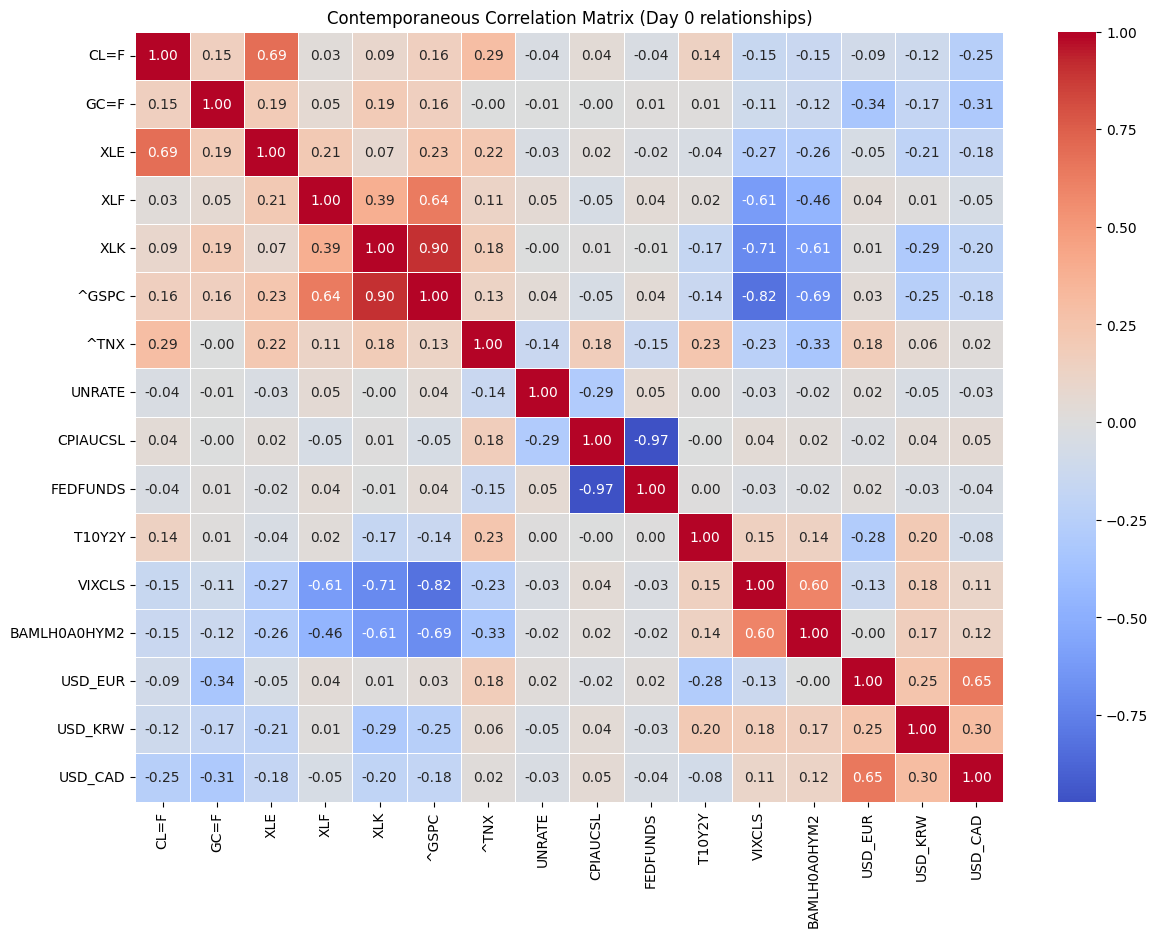

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_transform.corr(), 
    annot=True,       # Show the numbers
    cmap='coolwarm',  # Blue (Neg) to Red (Pos)
    center=0,         # Set 0 as the middle (white)
    fmt=".2f",        # 2 decimal places
    linewidths=0.5
)
plt.title("Contemporaneous Correlation Matrix (Day 0 relationships)")
plt.show()

# Analysis

In [14]:
# Install Tigramite and dependencies
!pip install Cython
!pip install tigramite
!pip install pandas numpy matplotlib seaborn
!pip install tigramite matplotlib pandas numpy

In [15]:
import sys

# 1. Install specifically for the active kernel
%pip install tigramite

# 2. Add the current environment's path to sys.path manually (emergency bypass)
if sys.prefix not in sys.path:
    sys.path.append(f"{sys.prefix}/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages")

# 3. Test the import immediately
try:
    import tigramite
    print("Success! Tigramite is now accessible.")
except ImportError:
    print("Still failing. See the 'Nuclear Option' below.")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Success! Tigramite is now accessible.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tigramite
from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr # Correct import for v5.0+
from tigramite import plotting as tp
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

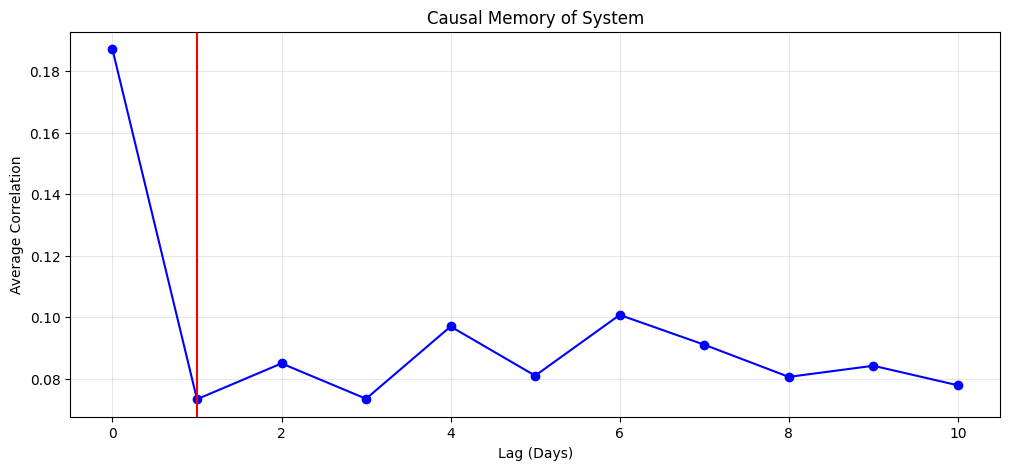

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite import plotting as tp

vals = df_transform.values
var_names = df_transform.columns.tolist()

# tigramite dataframe, mapping data to time indices for tau optimization later
dataframe = dp.DataFrame(vals, datatime=np.arange(len(vals)), var_names=var_names)

parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=0)

data_source = df_transform
vals = StandardScaler().fit_transform(data_source.values)
var_names = df_transform.columns.tolist()
T_num = len(vals)

dataframe = dp.DataFrame(vals, datatime=np.arange(T_num), var_names=var_names)
#initilize PCMCI
parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=0)

#tau optimization up to tau=10
tau_results = pcmci.get_lagged_dependencies(tau_max=10, val_only=False)
val_matrix = tau_results['val_matrix']

#avg corrlation for each tau without self dependencies
avg_decays = []
n_vars = val_matrix.shape[0]
for tau in range(11):
    lag_matrix = np.abs(val_matrix[:, :, tau])
    np.fill_diagonal(lag_matrix, 0)
    avg_decays.append(np.sum(lag_matrix) / (n_vars * (n_vars - 1)))


plt.figure(figsize=(12, 5))
plt.title('Causal Memory of System')
plt.plot(range(11), avg_decays, marker='o', color='blue')
plt.xlabel('Lag (Days)')
plt.ylabel('Average Correlation')
plt.axvline(x=1, color='red')
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
optimal_tau = 3

In [19]:
# optimizing alpha
alphas = [0.001, 0.01, 0.05, 0.1]
best_bic = float('inf')
best_alpha = None
results_dict = {}

for alpha in alphas:
    # RUN SPECIALIZED MODEL
    # tau_min=1 removes instant noise
    results = pcmci.run_pcmci(tau_min=1, tau_max=optimal_tau, pc_alpha=alpha)
    
    # calc BIC (Bayesian Information Criterion)
    graph = results['graph']
    n_edges = np.count_nonzero(graph != "")
    strength_sum = np.sum(np.abs(results['val_matrix'][graph != ""]))
    
    T_eff = T_num - optimal_tau
    
    # BIC: Penalty for Edges - Reward for Fit
    bic = (n_edges * np.log(T_eff)) - (2 * strength_sum * T_eff)
    
    results_dict[alpha] = results
    
    print(f"Alpha: {alpha:<5} | Edges: {n_edges:<3} | BIC: {bic:.0f}")
    
    if bic < best_bic:
        best_bic = bic
        best_alpha = alpha

print(f"Specialized Alpha: {best_alpha} (Lowest BIC)")

Alpha: 0.001 | Edges: 34  | BIC: -1572
Alpha: 0.01  | Edges: 35  | BIC: -1649
Alpha: 0.05  | Edges: 37  | BIC: -1749
Alpha: 0.1   | Edges: 35  | BIC: -1739
Specialized Alpha: 0.05 (Lowest BIC)


In [20]:


split_idx = int(len(vals) * 0.8)
train_vals = vals[:split_idx]
test_vals = vals[split_idx:]

# splitting training and testing based on time series data
train_df = dp.DataFrame(train_vals, datatime=np.arange(len(train_vals)), var_names = var_names)
test_df = dp.DataFrame(test_vals, datatime=np.arange(len(test_vals)), var_names = var_names)

parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=train_df, cond_ind_test=parcorr, verbosity=0)

baseline = pcmci.run_pcmci(tau_min=1, tau_max=5, pc_alpha=0.05)
specialized = pcmci.run_pcmci(tau_min=1, tau_max=2, pc_alpha=0.1)

In [ ]:
## Visualizing 

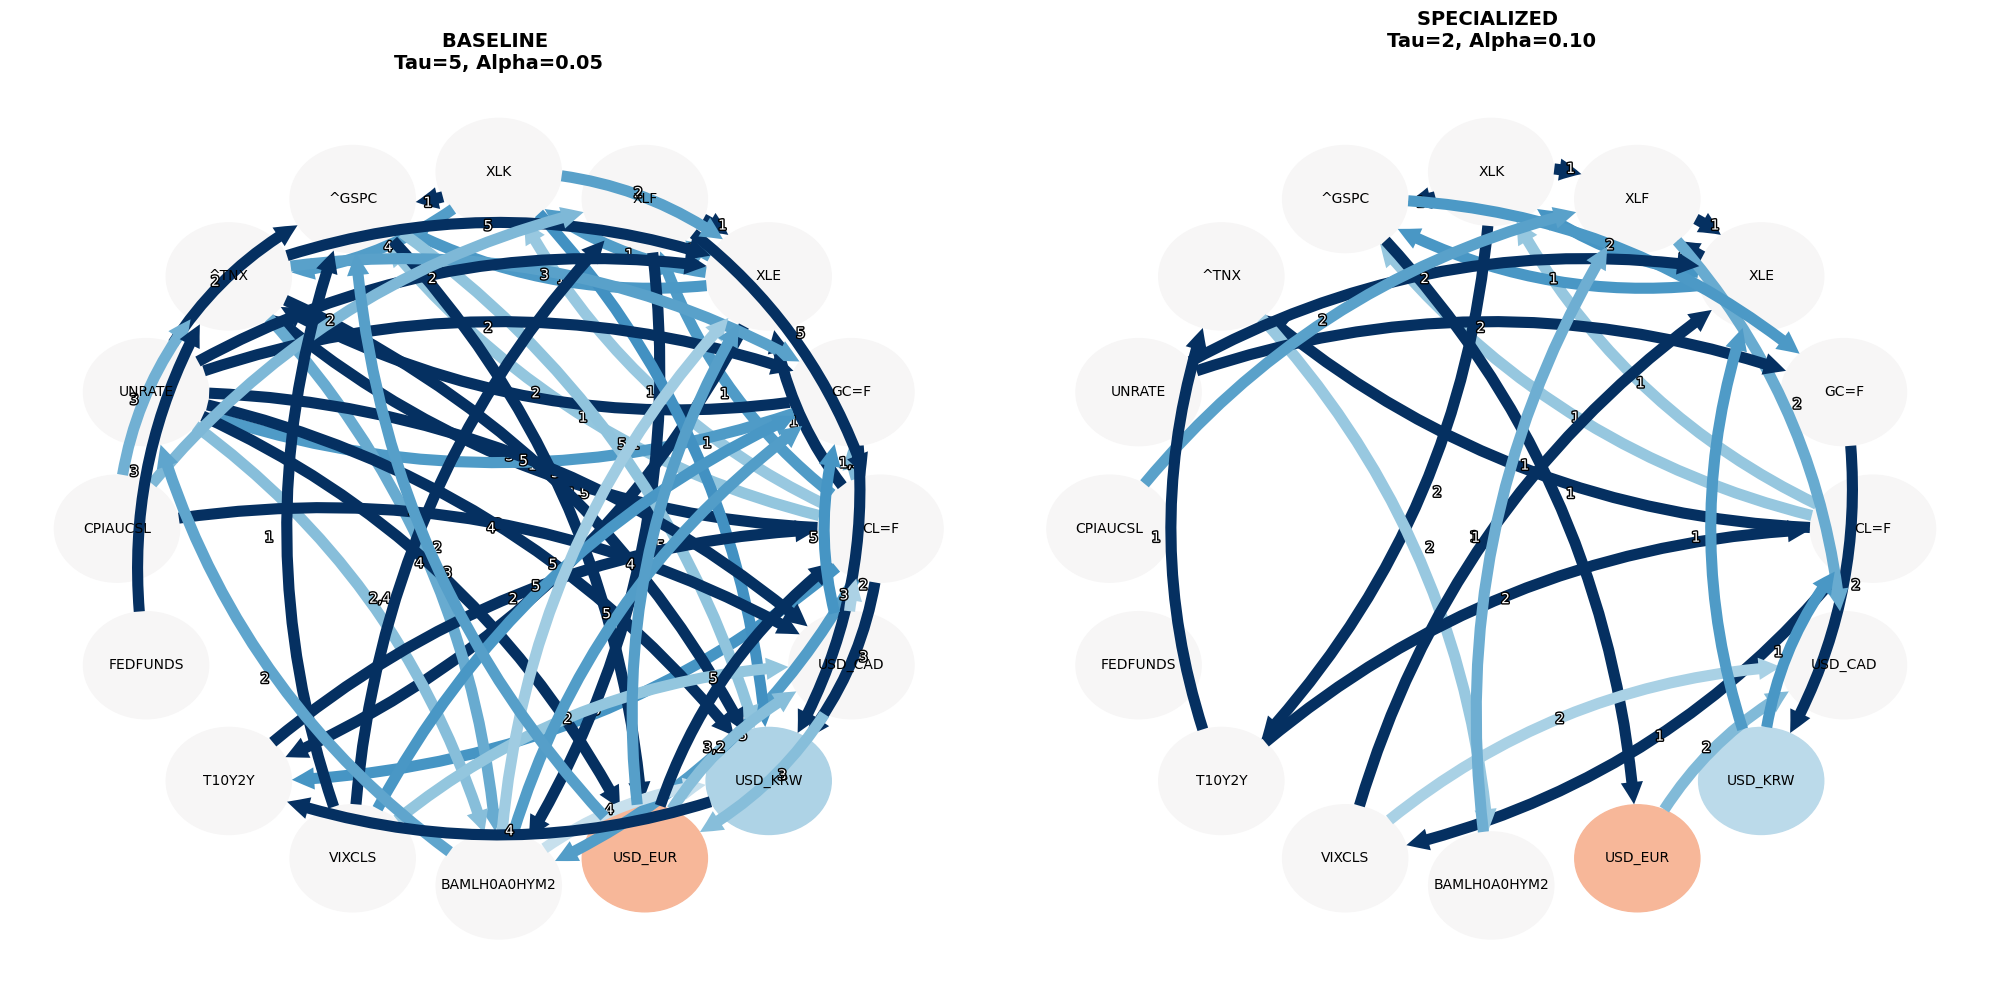

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# plot baseline
tp.plot_graph(
    val_matrix=baseline['val_matrix'],
    graph=baseline['graph'],
    var_names=var_names,
    vmin_edges=0.05,
    show_colorbar=False,
    label_fontsize=10,
    fig_ax=(fig, axes[0]) 
)
axes[0].set_title(f"BASELINE \nTau=5, Alpha=0.05", fontsize=14, fontweight='bold')

# Plot Specialized
tp.plot_graph(
    val_matrix=specialized['val_matrix'],
    graph=specialized['graph'],
    var_names=var_names,
    vmin_edges=0.05,
    show_colorbar=False,
    label_fontsize=10,
    fig_ax=(fig, axes[1])
)
axes[1].set_title(f"SPECIALIZED \nTau=2, Alpha=0.10\n", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
